## Classification Models Performance and Complexity Profiles


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science',"no-latex"])

In [3]:
# 1. Define Paths using pathlib
DATA_DIR = Path().cwd().parents[1] / "data" / "metrics"
OUTPUT_DIR = Path(".")

In [ ]:
# Load the classification dataset
csv_path = DATA_DIR / "classification_models.csv"
df_cls = pd.read_csv(csv_path)

# Sort models by baseline accuracy
df_cls = df_cls.sort_values(by="accuracy", ascending=True)

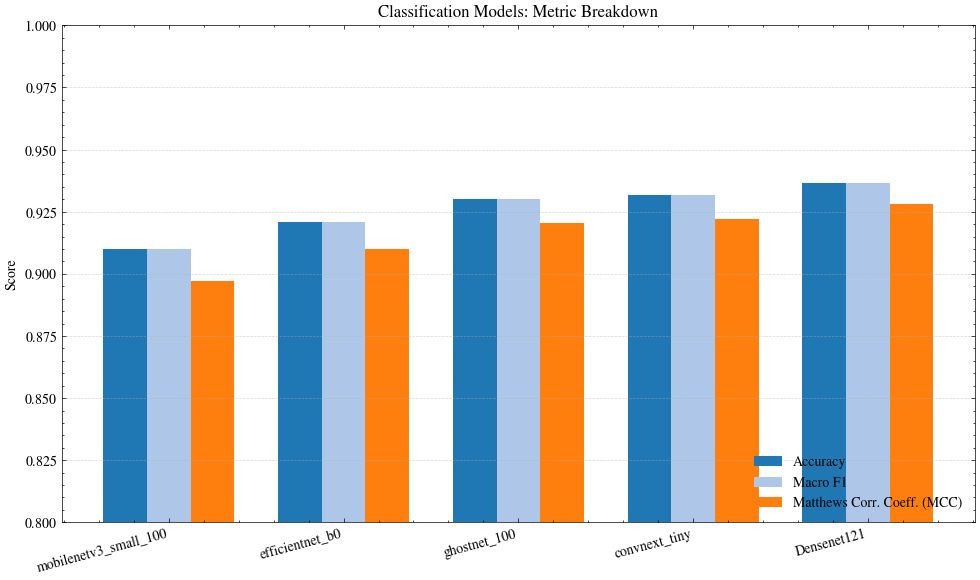

In [ ]:
# 2. Plot 1: Core Performance Metrics Profile
fig3, ax3 = plt.subplots(figsize=(10, 6))
indices_cls = range(len(df_cls))
bar_width_cls = 0.25

# Cluster 3 bars per model to evaluate classification accuracy nuances
ax3.bar(
    [i - bar_width_cls for i in indices_cls],
    df_cls["accuracy"],
    bar_width_cls,
    label="Accuracy",
    color="#1f77b4",
)
ax3.bar(
    indices_cls,
    df_cls["macroF1"],
    bar_width_cls,
    label="Macro F1",
    color="#aec7e8",
)
ax3.bar(
    [i + bar_width_cls for i in indices_cls],
    df_cls["mcc"],
    bar_width_cls,
    label="Matthews Corr. Coeff. (MCC)",
    color="#ff7f0e",
)

ax3.set_xticks(indices_cls)
ax3.set_xticklabels(df_cls["modelName"], rotation=15, ha="right")
ax3.set_ylabel("Score")
ax3.set_ylim(0.8, 1.0)  # Bound y-limit to focus on upper tier model discrepancy
ax3.set_title("Classification Models: Metric Breakdown")
ax3.legend(loc="lower right")
ax3.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
fig3.savefig(OUTPUT_DIR / "classification_metrics_comparison.png", dpi=300)
plt.show()

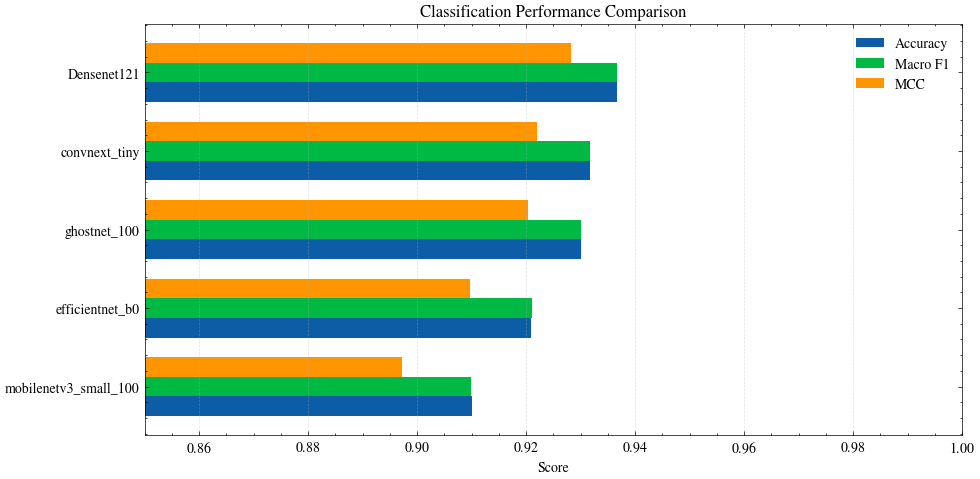

In [7]:
import numpy as np

metrics = ["accuracy", "macroF1", "mcc"]
labels = ["Accuracy", "Macro F1", "MCC"]
df_perf = df_cls.sort_values("accuracy")
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(df_perf))
h = 0.25
for i, metric in enumerate(metrics):
    ax.barh(y + (i - 1) * h, df_perf[metric], height=h, label=labels[i])
ax.set_yticks(y)
ax.set_yticklabels(df_perf["modelName"])
ax.set_xlim(0.85, 1.0)

ax.set_xlabel("Score")
ax.set_title("Classification Performance Comparison")
ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.legend()

plt.tight_layout()
plt.savefig("fig1_ranked_performance.png", dpi=300)
plt.show()

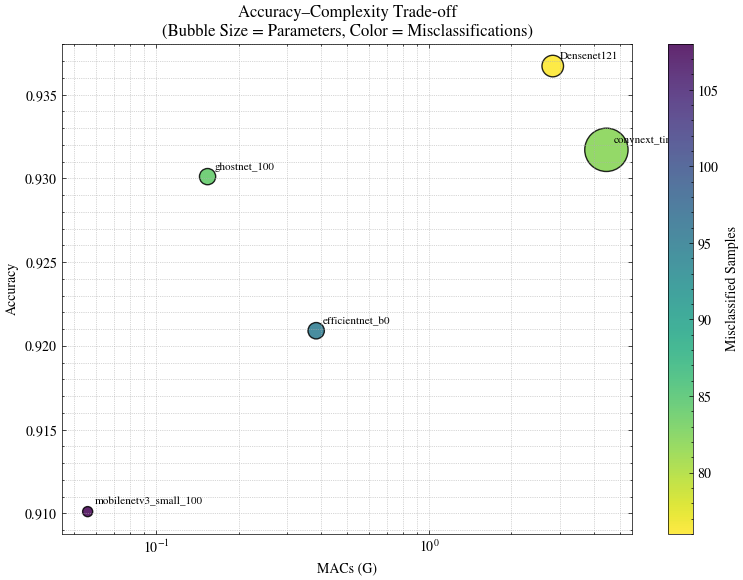

In [8]:
# %%
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df_cls["macsG"],
    df_cls["accuracy"],
    s=df_cls["paramsM"] * 35,
    c=df_cls["misclassified"],
    cmap="viridis_r",
    edgecolors="black",
    alpha=0.85
)

for _, row in df_cls.iterrows():
    ax.annotate(
        row["modelName"],
        (row["macsG"], row["accuracy"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xscale("log")

ax.set_xlabel("MACs (G)")
ax.set_ylabel("Accuracy")

ax.set_title(
    "Accuracy–Complexity Trade-off\n"
    "(Bubble Size = Parameters, Color = Misclassifications)"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Misclassified Samples")

ax.grid(True, which="both", linestyle=":")

plt.tight_layout()
plt.savefig("fig2_accuracy_complexity_tradeoff.png", dpi=300)
plt.show()

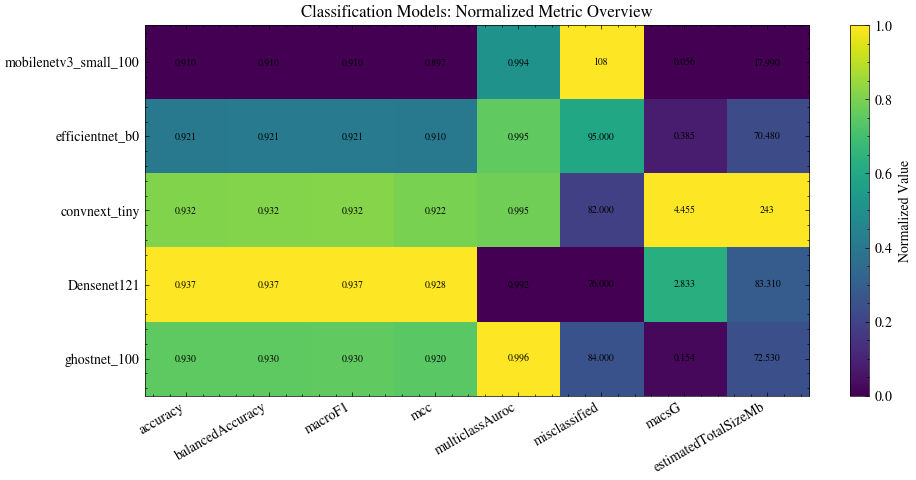

In [9]:
# %%
import numpy as np

heat_cols = [
    "accuracy",
    "balancedAccuracy",
    "macroF1",
    "mcc",
    "multiclassAuroc",
    "misclassified",
    "macsG",
    "estimatedTotalSizeMb",
]

heat = df_cls.set_index("modelName")[heat_cols]
heat_norm = (heat - heat.min()) / (heat.max() - heat.min())
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_norm, aspect="auto")
ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=30, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(len(heat.index)):
    for j in range(len(heat_cols)):
        value = heat.iloc[i, j]
        if value > 100:
            txt = f"{value:.0f}"
        else:
            txt = f"{value:.3f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=7)
plt.colorbar(im, label="Normalized Value")
ax.set_title("Classification Models: Normalized Metric Overview")
plt.tight_layout()
plt.savefig("fig3_metric_heatmap.png", dpi=300)
plt.show()

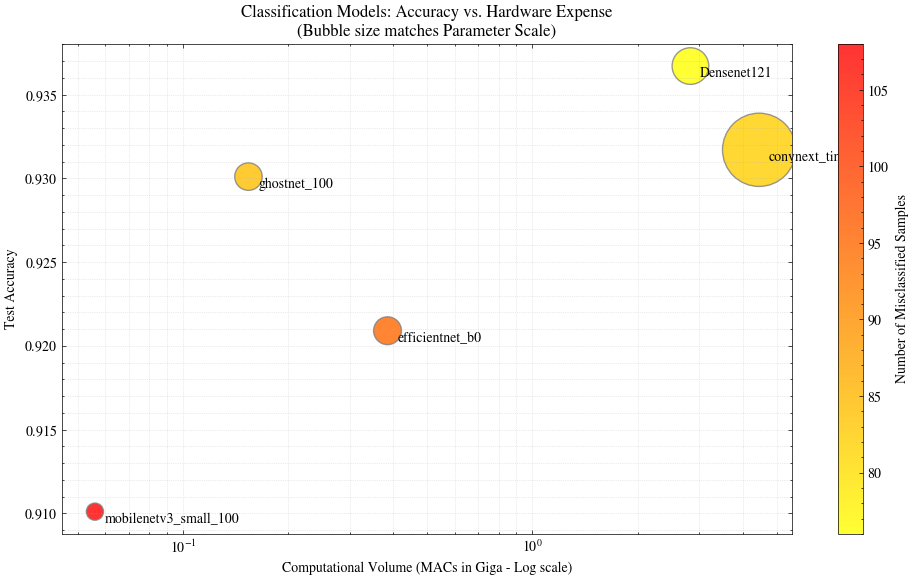

In [6]:
# 3. Plot 2: Operational Complexity (MACs) vs. Accuracy Curve
fig4, ax4 = plt.subplots(figsize=(10, 6))

# Bubble sizes map to Parameter volume, color identifies frequency of misclassifications
scatter4 = ax4.scatter(
    df_cls["macsG"],
    df_cls["accuracy"],
    s=df_cls["totalParameters"] / 1e4,
    c=df_cls["misclassified"],
    cmap="autumn_r",
    alpha=0.8,
    edgecolors="grey",
)

for idx, row in df_cls.iterrows():
    ax4.annotate(
        row["modelName"],
        (row["macsG"], row["accuracy"]),
        xytext=(7, -8),
        textcoords="offset points",
    )

ax4.set_xscale(
    "log"
)  # Uses logarithmic scaling to accommodate small architectures alongside ConvNeXt
ax4.set_xlabel("Computational Volume (MACs in Giga - Log scale)")
ax4.set_ylabel("Test Accuracy")
ax4.set_title(
    "Classification Models: Accuracy vs. Hardware Expense\n(Bubble size matches Parameter Scale)"
)
cbar4 = fig4.colorbar(scatter4, ax=ax4)
cbar4.set_label("Number of Misclassified Samples")
ax4.grid(True, which="both", linestyle=":", alpha=0.5)

plt.tight_layout()
fig4.savefig(OUTPUT_DIR / "classification_complexity_vs_accuracy.png", dpi=300)
plt.show()

In [ ]:
df_eff = df_cls.copy()

df_eff["efficiency"] = (
    df_eff["accuracy"]
    /
    df_eff["macsG"]
)

df_eff = df_eff.sort_values(
    "efficiency",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.barh(
    df_eff["modelName"],
    df_eff["efficiency"]
)

ax.set_xlabel("Accuracy / MACs")

ax.set_title(
    "Deployment Efficiency Ranking"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fig4_efficiency_ranking.png",
    dpi=300
)

plt.show()